# 🎯 HR Analytics – Predicting Job Change of Data Scientists

**Dataset:** [Kaggle – HR Analytics: Job Change of Data Scientists](https://www.kaggle.com/datasets/arashnic/hr-analytics-job-change-of-data-scientists/data)

---

## 📌 Project Objective
A company that trains data scientists wants to know **which candidates are likely to look for a new job** after training, so it can optimize recruitment costs and plan retention strategies.

**Target variable:** `target`
- `0` → Not looking for a job change
- `1` → Looking for a job change

---

## 🗺️ Pipeline Overview

| # | Step | Description |
|---|------|-------------|
| 0 | Setup | Install dependencies & download data |
| 1 | Load Data | Read train/test CSVs |
| 2 | EDA | Explore distributions, class balance, relationships |
| 3 | Missing Values | Heatmap + smart imputation |
| 4 | Outlier Handling | Box plots + percentile capping |
| 5 | Feature Cleaning | Parse string-encoded numerics |
| 6 | Encoding | Ordinal + One-Hot encoding |
| 7 | Feature Engineering | Create 3 interaction features |
| 8 | Column Selection | Drop irrelevant columns |
| 9 | Scaling | StandardScaler (fit on train only) |
| 10 | Train/Val Split | 80/20 stratified split |
| 11 | Class Imbalance | SMOTE oversampling on train set |
| 12 | Correlation Analysis | Heatmap of final features |
| 13 | Model Training | Logistic Regression, Random Forest, XGBoost |
| 14 | Evaluation | Accuracy, F1, ROC-AUC, Confusion Matrix |
| 15 | Model Comparison | Side-by-side metrics + ROC curves |
| 16 | Feature Importance | Top drivers from best model |
| 17 | Save Outputs | Cleaned data + predictions |


## 0️⃣ Setup – Install Dependencies & Download Data

In [ ]:
!pip install kagglehub imbalanced-learn xgboost -q

import kagglehub, shutil, os, warnings
warnings.filterwarnings('ignore')

path = kagglehub.dataset_download('arashnic/hr-analytics-job-change-of-data-scientists')
dest = '/content/hr_data'
os.makedirs(dest, exist_ok=True)
for f in os.listdir(path):
    shutil.copy(os.path.join(path, f), dest)

print('✅ Files available:', os.listdir(dest))


100%|██████████| 295k/295k [00:00<00:00, 628kB/s]

Extracting files...
✅ Files available: ['aug_test.csv', 'sample_submission.csv', 'aug_train.csv']


## 1️⃣ Imports & Load Data

We load all required libraries upfront for reproducibility, and read the train/test CSVs into DataFrames.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              classification_report, confusion_matrix, roc_curve)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
SEED = 42

train = pd.read_csv('/content/hr_data/aug_train.csv')
test  = pd.read_csv('/content/hr_data/aug_test.csv')

print(f'Train shape : {train.shape}')
print(f'Test  shape : {test.shape}')
train.head()


Train shape : (19158, 14)
Test  shape : (2129, 13)


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


## 2️⃣ Exploratory Data Analysis (EDA)

Before preprocessing we explore:
- **Data types & null counts** – to inform imputation strategy
- **Target distribution** – to assess class imbalance
- **Numerical distributions** – to spot skew and outliers
- **Categorical distributions** – to understand cardinality
- **Feature vs Target relationships** – to identify predictive signals


In [ ]:
print('='*60)
print('TRAIN INFO')
print('='*60)
train.info()
print()
print('DESCRIPTIVE STATISTICS')
train.describe(include='all').T


TRAIN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), ob

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
enrollee_id,19158.0,NaN,NaN,NaN,16875.358179,9616.292592,1.0,8554.25,16982.5,25169.75,33380.0
city,19158,123,city_103,4355,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city_development_index,19158.0,NaN,NaN,NaN,0.828848,0.123362,0.448,0.74,0.903,0.92,0.949
gender,14650,3,Male,13221,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relevent_experience,19158,2,Has relevent experience,13792,NaN,NaN,NaN,NaN,NaN,NaN,NaN
enrolled_university,18772,3,no_enrollment,13817,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,18698,5,Graduate,11598,NaN,NaN,NaN,NaN,NaN,NaN,NaN
major_discipline,16345,6,STEM,14492,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experience,19093,22,>20,3286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_size,13220,8,50-99,3083,NaN,NaN,NaN,NaN,NaN,NaN,NaN


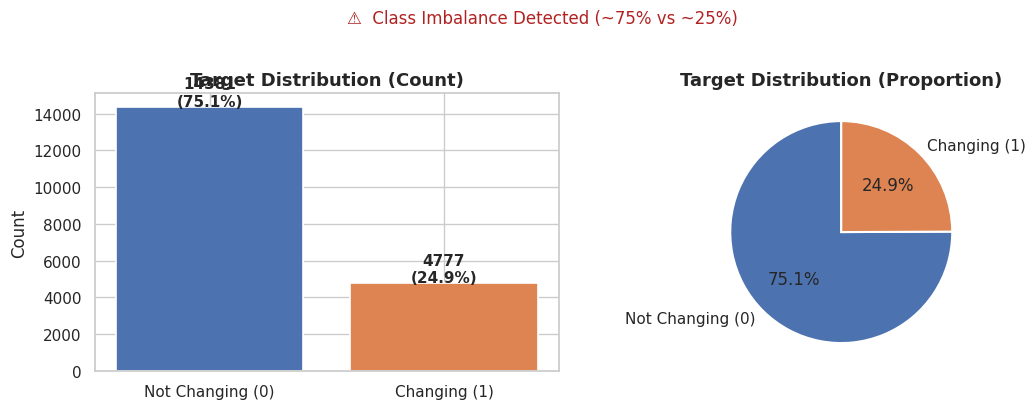

Class 0: 14381 (75.1%)
Class 1: 4777 (24.9%)
Imbalance ratio: 3.01:1


In [ ]:
counts = train['target'].value_counts()
pct    = train['target'].value_counts(normalize=True).mul(100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['Not Changing (0)', 'Changing (1)'], counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=1.2)
for i, (v, p) in enumerate(zip(counts.values, pct.values)):
    axes[0].text(i, v + 40, f'{v}\n({p}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Target Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=['Not Changing (0)', 'Changing (1)'],
            autopct='%1.1f%%', colors=['#4C72B0','#DD8452'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Target Distribution (Proportion)', fontsize=13, fontweight='bold')

plt.suptitle('⚠️  Class Imbalance Detected (~75% vs ~25%)', fontsize=12,
             color='firebrick', y=1.02)
plt.tight_layout()
plt.show()

print(f'Class 0: {counts[0]} ({pct[0]}%)')
print(f'Class 1: {counts[1]} ({pct[1]}%)')
print(f'Imbalance ratio: {counts[0]/counts[1]:.2f}:1')


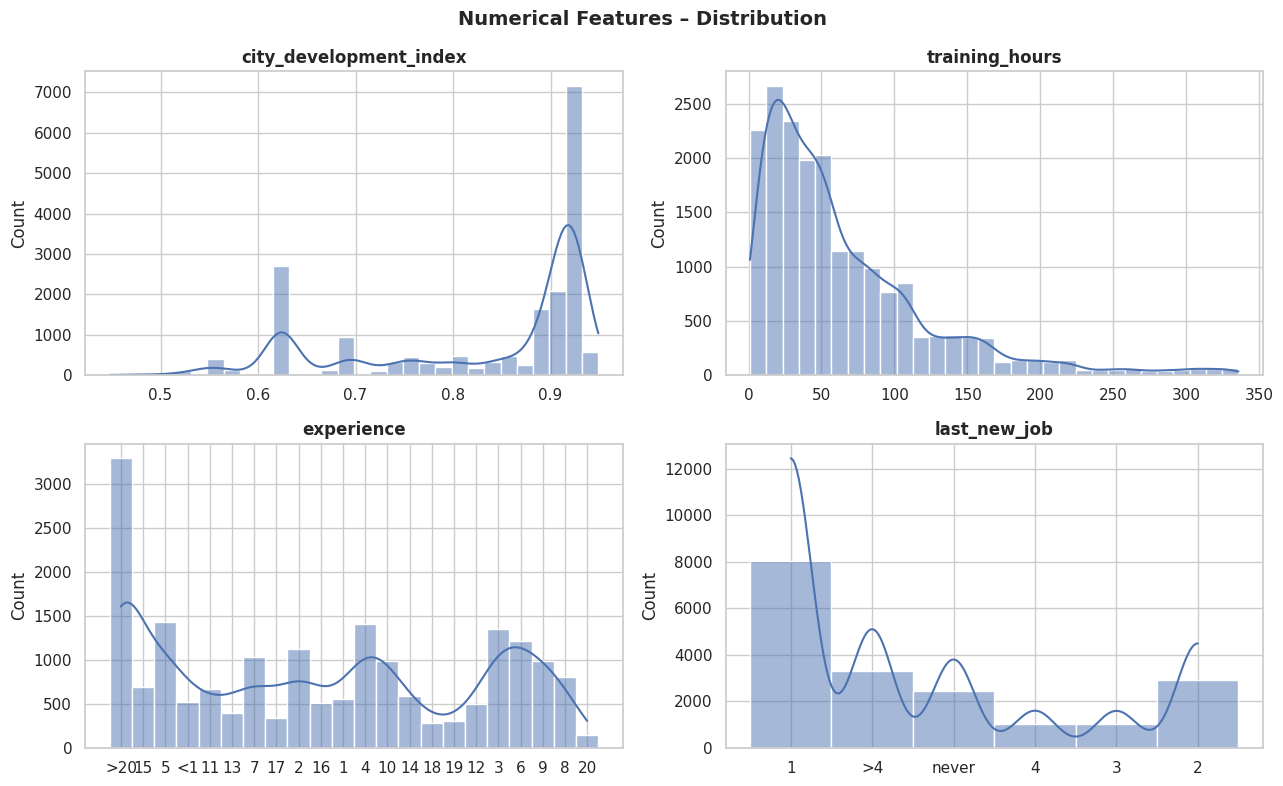

In [ ]:
num_cols = ['city_development_index', 'training_hours', 'experience', 'last_new_job']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(train[col].dropna(), kde=True, ax=ax, color='#4C72B0', bins=30)
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Numerical Features – Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


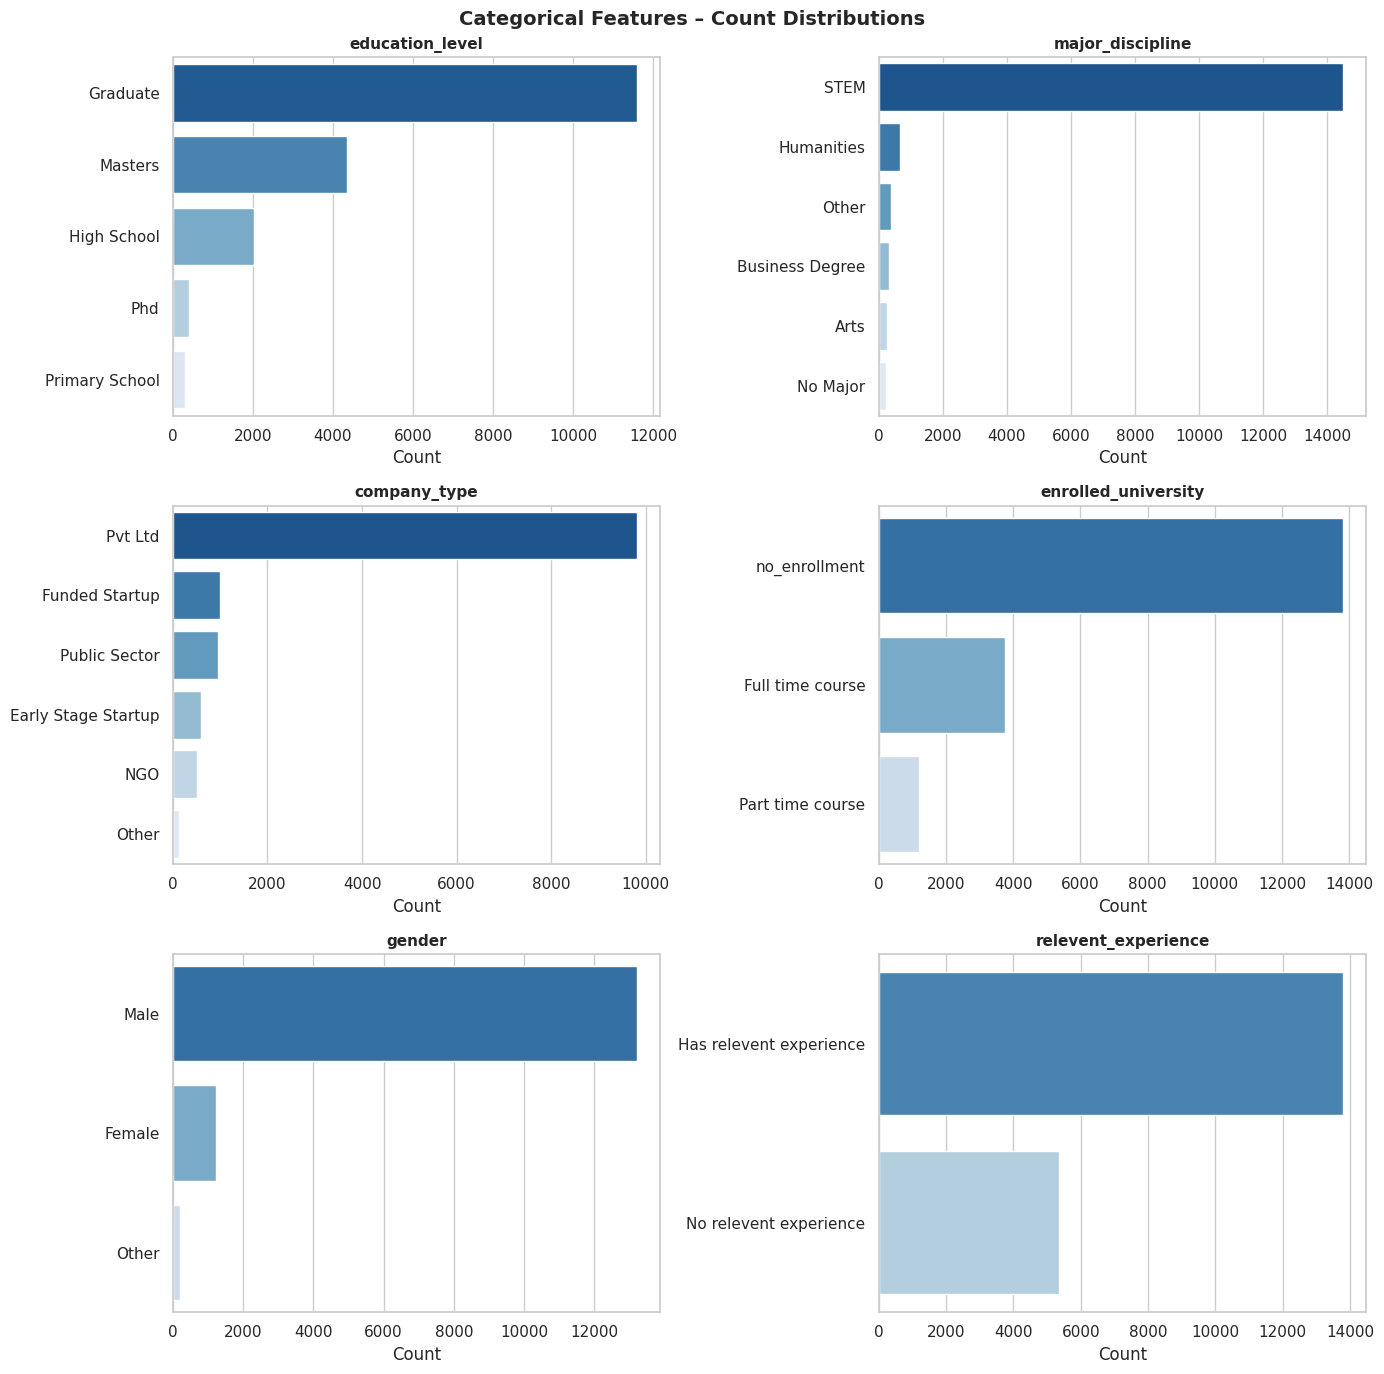

In [ ]:
cat_cols = ['education_level', 'major_discipline', 'company_type',
            'enrolled_university', 'gender', 'relevent_experience']

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    order = train[col].value_counts().index
    sns.countplot(y=col, data=train, order=order, ax=ax,
                  palette='Blues_r', edgecolor='white')
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Count')
    ax.set_ylabel('')

plt.suptitle('Categorical Features – Count Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


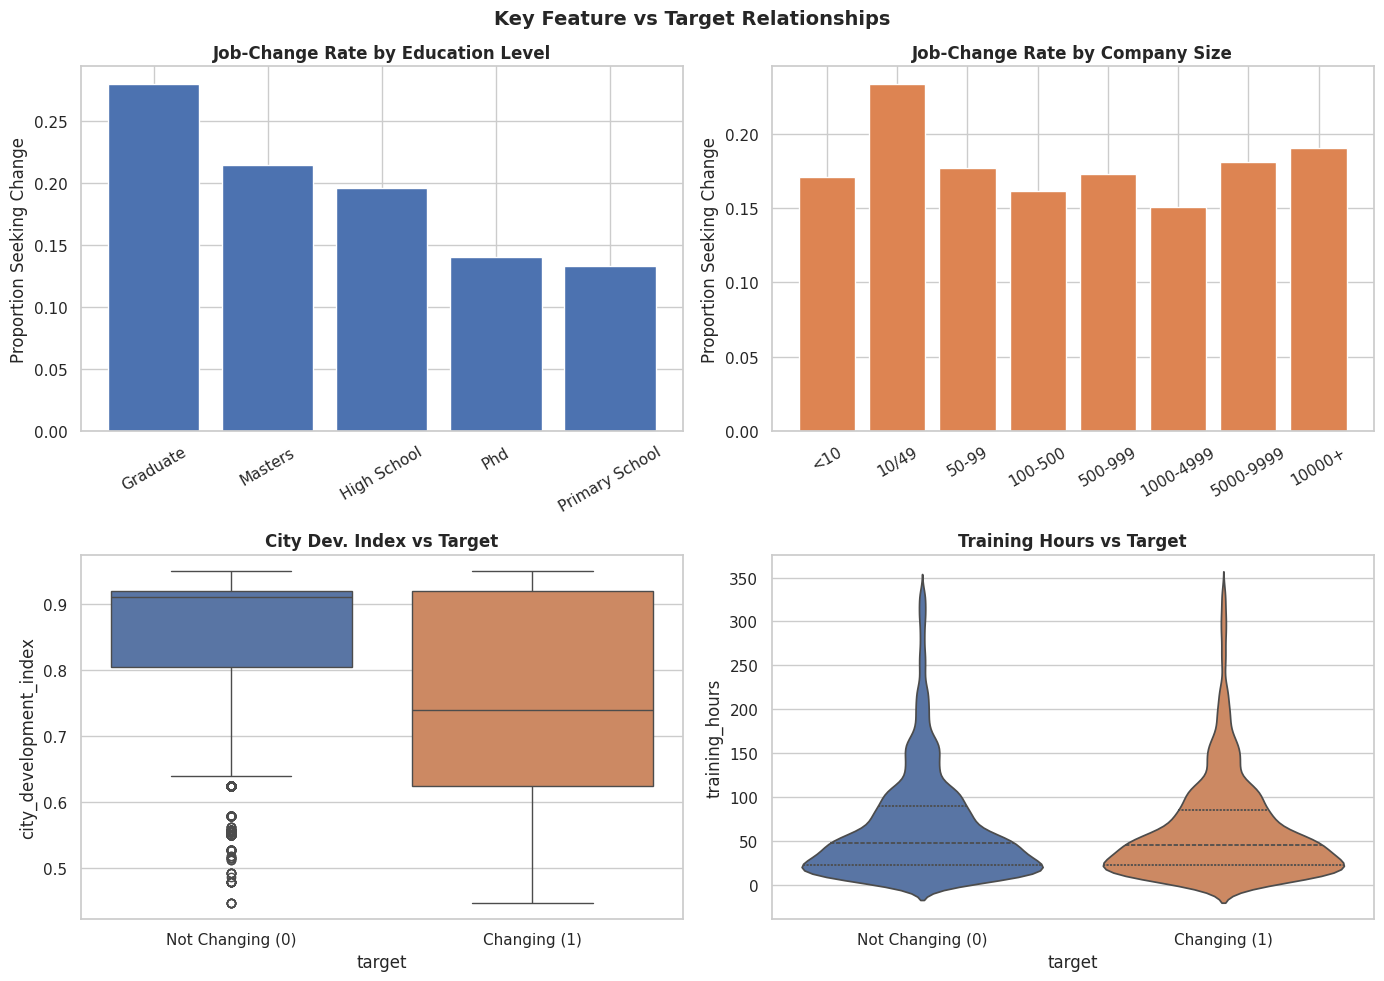

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

edu_target = train.groupby('education_level')['target'].mean().sort_values(ascending=False)
axes[0,0].bar(edu_target.index, edu_target.values, color='#4C72B0', edgecolor='white')
axes[0,0].set_title('Job-Change Rate by Education Level', fontweight='bold')
axes[0,0].set_ylabel('Proportion Seeking Change')
axes[0,0].tick_params(axis='x', rotation=30)

size_order = ['<10','10/49','50-99','100-500','500-999','1000-4999','5000-9999','10000+']
size_target = train.groupby('company_size')['target'].mean().reindex(size_order).dropna()
axes[0,1].bar(size_target.index, size_target.values, color='#DD8452', edgecolor='white')
axes[0,1].set_title('Job-Change Rate by Company Size', fontweight='bold')
axes[0,1].set_ylabel('Proportion Seeking Change')
axes[0,1].tick_params(axis='x', rotation=30)

sns.boxplot(x='target', y='city_development_index', data=train,
            palette=['#4C72B0','#DD8452'], ax=axes[1,0])
axes[1,0].set_title('City Dev. Index vs Target', fontweight='bold')
axes[1,0].set_xticklabels(['Not Changing (0)', 'Changing (1)'])

sns.violinplot(x='target', y='training_hours', data=train,
               palette=['#4C72B0','#DD8452'], ax=axes[1,1], inner='quartile')
axes[1,1].set_title('Training Hours vs Target', fontweight='bold')
axes[1,1].set_xticklabels(['Not Changing (0)', 'Changing (1)'])

plt.suptitle('Key Feature vs Target Relationships', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 3️⃣ Missing Value Analysis & Imputation

**Strategy:**
- **Categorical columns** → fill with `'Unknown'` — treats missingness as its own category and preserves the signal
- **Numerical columns** → fill with **median** — robust to outliers and skewed distributions

> Both train and test are imputed with the **same function** to avoid any data leakage.


Columns with missing values:
                     Missing Count  Missing %
company_type                  6140      32.05
company_size                  5938      30.99
gender                        4508      23.53
major_discipline              2813      14.68
education_level                460       2.40
last_new_job                   423       2.21
enrolled_university            386       2.01
experience                      65       0.34


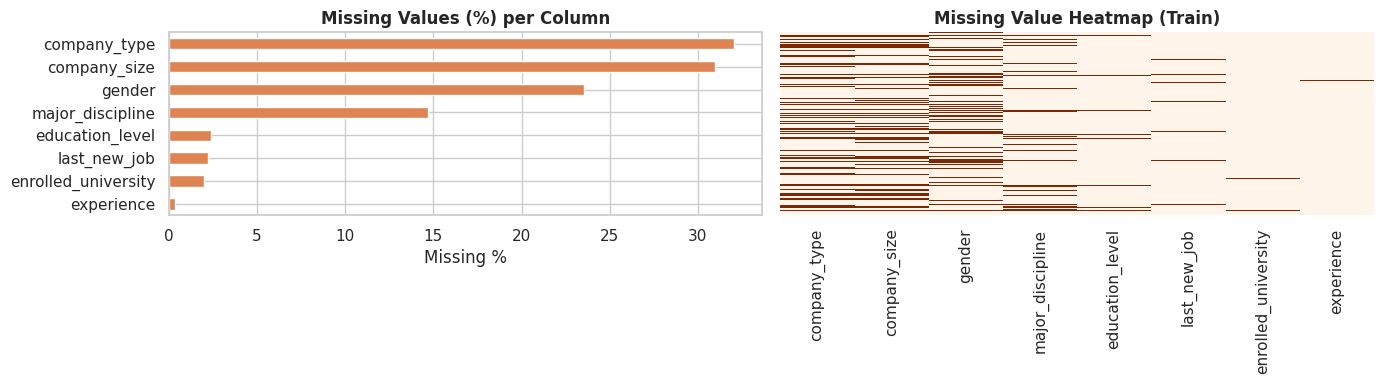

In [ ]:
missing     = train.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)
missing_df  = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_with = missing_df[missing_df['Missing Count'] > 0]

print('Columns with missing values:')
print(missing_with.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

missing_with['Missing %'].sort_values().plot(
    kind='barh', ax=axes[0], color='#DD8452', edgecolor='white')
axes[0].set_title('Missing Values (%) per Column', fontweight='bold')
axes[0].set_xlabel('Missing %')

sns.heatmap(train[missing_with.index].isnull(), cbar=False,
            yticklabels=False, cmap='Oranges', ax=axes[1])
axes[1].set_title('Missing Value Heatmap (Train)', fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
def impute_df(df):
    df = df.copy()
    cat_cols = df.select_dtypes(include='object').columns
    num_cols = [c for c in df.select_dtypes(include=np.number).columns
                if c not in ['enrollee_id', 'target']]
    for col in cat_cols:
        df[col] = df[col].fillna('Unknown')
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())
    return df

train = impute_df(train)
test  = impute_df(test)

print(f'Missing after imputation – Train: {train.isnull().sum().sum()}')
print(f'Missing after imputation – Test : {test.isnull().sum().sum()}')
print('✅ Imputation complete')


Missing after imputation – Train: 0
Missing after imputation – Test : 0
✅ Imputation complete


## 4️⃣ Outlier Detection & Handling

We check the two numerical features for extreme values using box plots.

**`training_hours`** is right-skewed — extreme high values are capped at the **99th percentile** to reduce distortion.
**`city_development_index`** is bounded [0, 1] by nature — no capping needed.


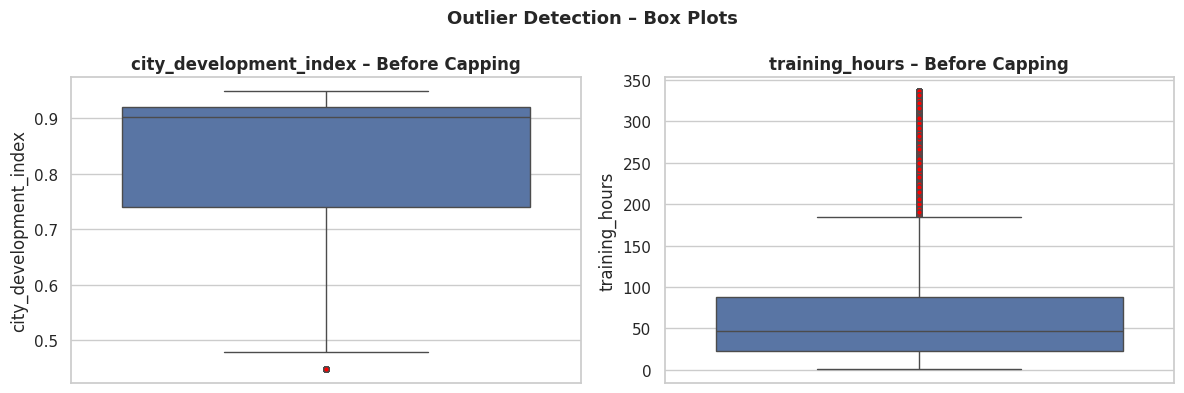

In [ ]:
num_features = ['city_development_index', 'training_hours']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, num_features):
    sns.boxplot(y=train[col], ax=ax, color='#4C72B0',
                flierprops=dict(marker='o', markerfacecolor='red', markersize=4))
    ax.set_title(f'{col} – Before Capping', fontweight='bold')
plt.suptitle('Outlier Detection – Box Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
cap_99 = train['training_hours'].quantile(0.99)
train['training_hours'] = train['training_hours'].clip(upper=cap_99)
test['training_hours']  = test['training_hours'].clip(upper=cap_99)

print(f'✅ training_hours capped at {cap_99:.0f} hrs (99th percentile)')
print(f'   New max: {train["training_hours"].max():.0f} hrs')


✅ training_hours capped at 302 hrs (99th percentile)
   New max: 302 hrs


## 5️⃣ Feature Cleaning

`experience` and `last_new_job` are stored as strings with special values (`'>20'`, `'<1'`, `'never'`, `'>4'`).
We convert them to clean integers so they can be used as numerical features.


In [ ]:
def clean_experience(val):
    if val == '>20': return 21
    if val == '<1':  return 0
    try:   return int(val)
    except: return np.nan

def clean_last_new_job(val):
    if val == '>4':    return 5
    if val == 'never': return 0
    try:   return int(val)
    except: return np.nan

for df in [train, test]:
    df['experience']    = df['experience'].apply(clean_experience)
    df['experience']    = df['experience'].fillna(df['experience'].median())
    df['last_new_job']  = df['last_new_job'].apply(clean_last_new_job)
    df['last_new_job']  = df['last_new_job'].fillna(df['last_new_job'].median())

print('experience    – unique values:', sorted(train['experience'].unique()))
print('last_new_job  – unique values:', sorted(train['last_new_job'].unique()))
print('✅ Feature cleaning complete')


experience    – unique values: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0)]
last_new_job  – unique values: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
✅ Feature cleaning complete


## 6️⃣ Feature Encoding

| Feature | Method | Reason |
|---------|--------|--------|
| `education_level` | Ordinal | Natural order: Primary < High School < Graduate < Masters < PhD |
| `company_size` | Ordinal | Natural order by headcount bands |
| `gender`, `relevent_experience`, `enrolled_university`, `major_discipline`, `company_type` | One-Hot | No natural order; low-to-medium cardinality |

> After `pd.get_dummies`, we **align** train and test columns to handle any dummy categories present in one but not the other.


In [ ]:
edu_order = {'Unknown':0,'Primary School':1,'High School':2,
             'Graduate':3,'Masters':4,'Phd':5}
size_order = {'Unknown':0,'<10':1,'10/49':2,'50-99':3,'100-500':4,
              '500-999':5,'1000-4999':6,'5000-9999':7,'10000+':8}

for df in [train, test]:
    df['education_level_enc'] = df['education_level'].map(edu_order).fillna(0).astype(int)
    df['company_size_enc']    = df['company_size'].map(size_order).fillna(0).astype(int)

print('✅ Ordinal encoding done')
print('education_level_enc range:', train['education_level_enc'].min(),
      '–', train['education_level_enc'].max())


✅ Ordinal encoding done
education_level_enc range: 0 – 5


In [ ]:
ohe_cols = ['gender', 'relevent_experience', 'enrolled_university',
            'major_discipline', 'company_type']

train_enc = pd.get_dummies(train, columns=ohe_cols, drop_first=True)
test_enc  = pd.get_dummies(test,  columns=ohe_cols, drop_first=True)

train_enc, test_enc = train_enc.align(test_enc, join='left', axis=1, fill_value=0)

print('✅ One-Hot encoding done')
print(f'Train shape after OHE : {train_enc.shape}')
print(f'Test  shape after OHE : {test_enc.shape}')


✅ One-Hot encoding done
Train shape after OHE : (19158, 30)
Test  shape after OHE : (2129, 30)


## 7️⃣ Feature Engineering

We create **3 new features** to capture interactions not directly available in raw columns:

| New Feature | Formula | Intuition |
|-------------|---------|-----------|
| `hours_per_exp` | `training_hours / (experience + 1)` | Training intensity per year of experience |
| `cdi_x_exp` | `city_development_index × experience` | Combined urbanisation & seniority signal |
| `high_cdi` | `CDI ≥ 0.9` → 1, else 0 | Binary flag for highly developed cities |


In [ ]:
for df in [train_enc, test_enc]:
    df['hours_per_exp'] = df['training_hours'] / (df['experience'] + 1)
    df['cdi_x_exp']     = df['city_development_index'] * df['experience']
    df['high_cdi']      = (df['city_development_index'] >= 0.9).astype(int)

print('✅ Feature engineering done')
print('New features added: hours_per_exp, cdi_x_exp, high_cdi')


✅ Feature engineering done
New features added: hours_per_exp, cdi_x_exp, high_cdi


## 8️⃣ Drop Irrelevant / Redundant Columns

| Dropped Column | Reason |
|----------------|--------|
| `enrollee_id` | Arbitrary ID — no predictive value |
| `city` | Replaced by `city_development_index` + `high_cdi` |
| `education_level` | Replaced by `education_level_enc` (ordinal) |
| `company_size` | Replaced by `company_size_enc` (ordinal) |


In [ ]:
drop_cols = ['enrollee_id', 'city', 'education_level', 'company_size']

train_clean = train_enc.drop(columns=[c for c in drop_cols if c in train_enc.columns])
test_clean  = test_enc.drop(columns=[c for c in drop_cols if c in test_enc.columns])

if 'target' in test_clean.columns:
    test_clean = test_clean.drop(columns=['target'])

print(f'Train columns kept : {train_clean.shape[1]}')
print(f'Test  columns kept : {test_clean.shape[1]}')


Train columns kept : 29
Test  columns kept : 28


## 9️⃣ Scaling

We apply **StandardScaler** to continuous / high-range numerical columns.

> ⚠️ The scaler is **fit only on the training set** and then used to transform validation and test sets — this prevents data leakage.


In [ ]:
scale_cols = ['city_development_index', 'training_hours', 'experience',
              'last_new_job', 'hours_per_exp', 'cdi_x_exp']
scale_cols = [c for c in scale_cols if c in train_clean.columns]

scaler = StandardScaler()
train_clean[scale_cols] = scaler.fit_transform(train_clean[scale_cols])
test_clean[scale_cols]  = scaler.transform(test_clean[scale_cols])

print('✅ Scaling done')
print('\nMean ≈ 0, Std ≈ 1 for scaled columns:')
train_clean[scale_cols].describe().T[['mean','std']].round(3)


✅ Scaling done

Mean ≈ 0, Std ≈ 1 for scaled columns:


,mean,std
city_development_index,-0.0,1.0
training_hours,0.0,1.0
experience,0.0,1.0
last_new_job,0.0,1.0
hours_per_exp,0.0,1.0
cdi_x_exp,0.0,1.0


## 🔟 Train / Validation Split

We use an **80/20 stratified split** to ensure both sets preserve the original class ratio (~75/25).


In [ ]:
X = train_clean.drop(columns=['target'])
y = train_clean['target']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'X_train : {X_train.shape}  |  X_val : {X_val.shape}')
print(f'Train class balance → {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Val   class balance → {y_val.value_counts(normalize=True).round(3).to_dict()}')


X_train : (15326, 28)  |  X_val : (3832, 28)
Train class balance → {0.0: 0.751, 1.0: 0.249}
Val   class balance → {0.0: 0.751, 1.0: 0.249}


## 1️⃣1️⃣ Class Imbalance Handling – SMOTE

The dataset has a ~75:25 imbalance. Without correction, models are biased toward predicting class 0.

We apply **SMOTE (Synthetic Minority Over-sampling Technique)** only on the **training set** to generate synthetic minority samples.

> SMOTE is applied **after** the train/val split to prevent synthetic samples from leaking into the validation set.


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'Before SMOTE – Class 0: {(y_train==0).sum()}, Class 1: {(y_train==1).sum()}')
print(f'After  SMOTE – Class 0: {(y_train_sm==0).sum()}, Class 1: {(y_train_sm==1).sum()}')
print(f'Training set size after SMOTE: {X_train_sm.shape[0]} samples')
print('✅ SMOTE applied successfully')


Before SMOTE – Class 0: 11504, Class 1: 3822
After  SMOTE – Class 0: 11504, Class 1: 11504
Training set size after SMOTE: 23008 samples
✅ SMOTE applied successfully


## 1️⃣2️⃣ Correlation Analysis

We inspect the correlation matrix of all numerical and ordinal-encoded features to:
- Identify highly correlated feature pairs (potential redundancy)
- Understand which features have the strongest linear relationship with the target


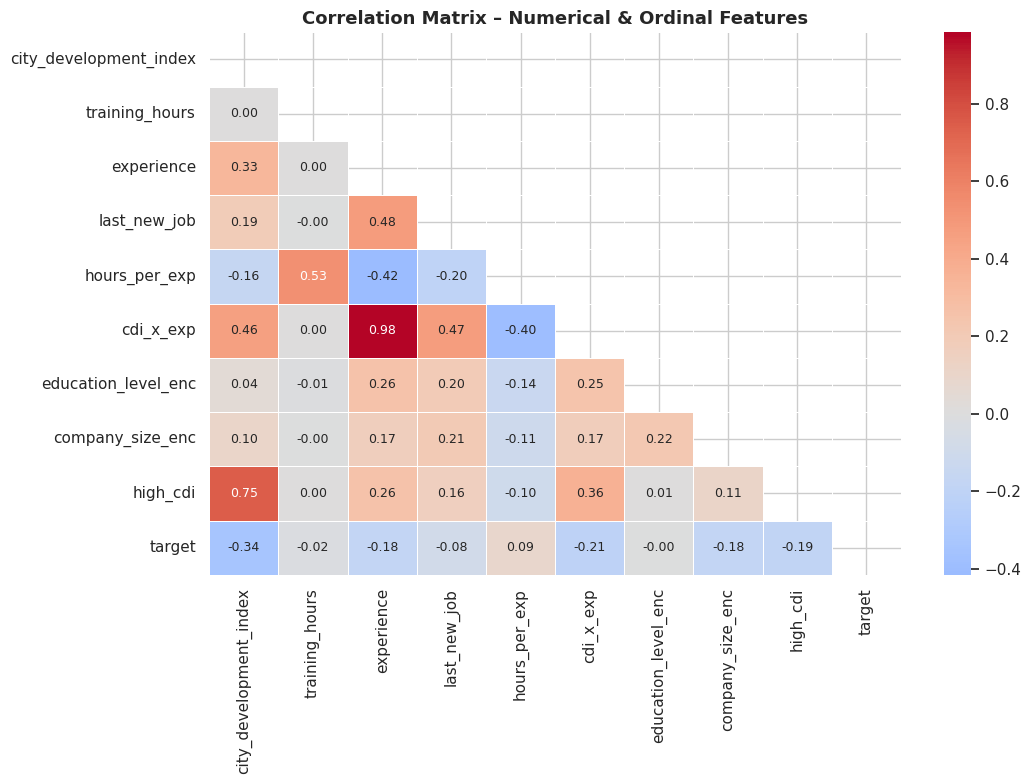


Top features correlated with target:
city_development_index    0.342
cdi_x_exp                 0.209
high_cdi                  0.189
company_size_enc          0.183
experience                0.176
hours_per_exp             0.090
last_new_job              0.085
training_hours            0.021
education_level_enc       0.004


In [ ]:
corr_cols = scale_cols + ['education_level_enc', 'company_size_enc', 'high_cdi', 'target']
corr_cols = [c for c in corr_cols if c in train_clean.columns]

corr_matrix = train_clean[corr_cols].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Correlation Matrix – Numerical & Ordinal Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop features correlated with target:')
print(corr_matrix['target'].drop('target').abs().sort_values(ascending=False).round(3).to_string())


## 1️⃣3️⃣ Model Training

We train **3 models** on the SMOTE-resampled training set:

| Model | Key Strengths |
|-------|--------------|
| **Logistic Regression** | Fast, interpretable, strong baseline |
| **Random Forest** | Handles non-linearity, robust to outliers, built-in feature importance |
| **XGBoost** | State-of-the-art gradient boosting, excellent on tabular data |

All models are evaluated on the **held-out validation set** (no SMOTE applied to val/test).


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=SEED, C=0.5),

    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=5,
        class_weight='balanced', random_state=SEED, n_jobs=-1),

    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
        random_state=SEED, eval_metric='logloss', verbosity=0)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    trained_models[name] = model
    print(f'✅ {name} trained')


✅ Logistic Regression trained
✅ Random Forest trained
✅ XGBoost trained


## 1️⃣4️⃣ Model Evaluation

We evaluate each model on the validation set using:
- **Accuracy** – overall correctness
- **F1 Score (macro)** – balance between precision and recall across both classes
- **ROC-AUC** – ability to distinguish between classes regardless of threshold
- **Confusion Matrix** – detailed breakdown of TP, TN, FP, FN
- **Classification Report** – per-class precision, recall, F1


In [ ]:
results = {}

for name, model in trained_models.items():
    y_pred      = model.predict(X_val)
    y_prob      = model.predict_proba(X_val)[:, 1]
    acc         = accuracy_score(y_val, y_pred)
    f1          = f1_score(y_val, y_pred, average='macro')
    roc         = roc_auc_score(y_val, y_prob)
    results[name] = {'Accuracy': acc, 'F1 (macro)': f1, 'ROC-AUC': roc,
                     'y_pred': y_pred, 'y_prob': y_prob}

    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  F1 (macro): {f1:.4f}')
    print(f'  ROC-AUC   : {roc:.4f}')
    print(f'\n  Classification Report:')
    print(classification_report(y_val, y_pred, target_names=['Not Changing', 'Changing']))



  Logistic Regression
  Accuracy  : 0.7383
  F1 (macro): 0.6914
  ROC-AUC   : 0.7670

  Classification Report:
              precision    recall  f1-score   support

Not Changing       0.88      0.75      0.81      2877
    Changing       0.48      0.70      0.57       955

    accuracy                           0.74      3832
   macro avg       0.68      0.73      0.69      3832
weighted avg       0.78      0.74      0.75      3832


  Random Forest
  Accuracy  : 0.7886
  F1 (macro): 0.7473
  ROC-AUC   : 0.8124

  Classification Report:
              precision    recall  f1-score   support

Not Changing       0.91      0.79      0.85      2877
    Changing       0.55      0.77      0.65       955

    accuracy                           0.79      3832
   macro avg       0.73      0.78      0.75      3832
weighted avg       0.82      0.79      0.80      3832


  XGBoost
  Accuracy  : 0.7351
  F1 (macro): 0.7028
  ROC-AUC   : 0.8101

  Classification Report:
              precision    r

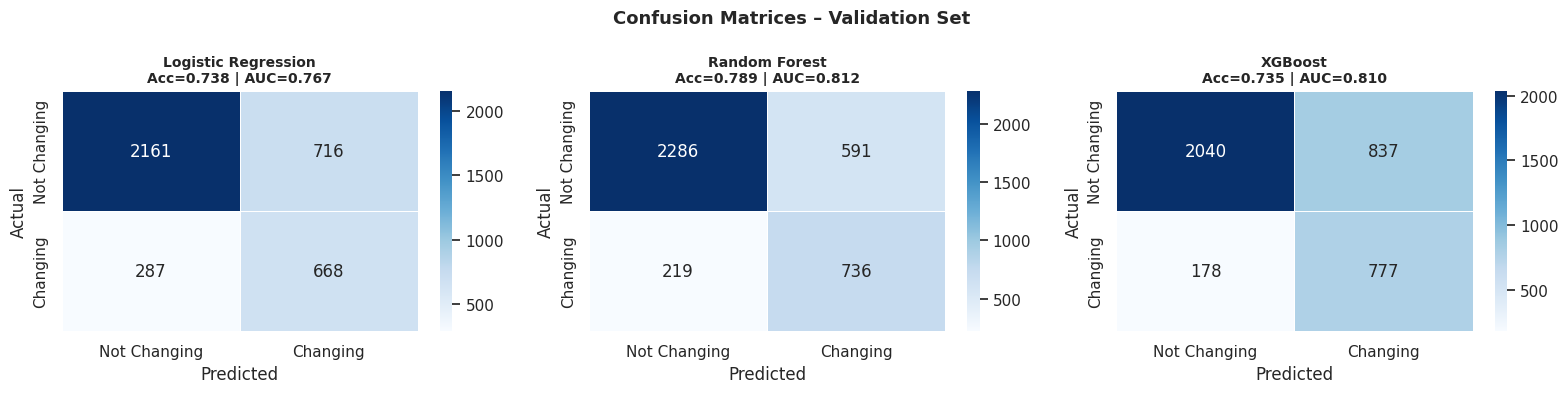

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_val, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Changing', 'Changing'],
                yticklabels=['Not Changing', 'Changing'],
                linewidths=0.5)
    ax.set_title(f'{name}\nAcc={res["Accuracy"]:.3f} | AUC={res["ROC-AUC"]:.3f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices – Validation Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 1️⃣5️⃣ Model Comparison

Side-by-side comparison of all three models across all metrics, plus **ROC curves** to visualise the full precision-recall trade-off.


In [ ]:
metrics_df = pd.DataFrame({
    name: {'Accuracy': res['Accuracy'],
           'F1 (macro)': res['F1 (macro)'],
           'ROC-AUC': res['ROC-AUC']}
    for name, res in results.items()
}).T.round(4)

print('Model Performance Summary:')
print(metrics_df.to_string())

best_model_name = metrics_df['ROC-AUC'].idxmax()
print(f'\n🏆 Best model by ROC-AUC: {best_model_name} ({metrics_df.loc[best_model_name,"ROC-AUC"]:.4f})')


Model Performance Summary:
                     Accuracy  F1 (macro)  ROC-AUC
Logistic Regression    0.7383      0.6914   0.7670
Random Forest          0.7886      0.7473   0.8124
XGBoost                0.7351      0.7028   0.8101

🏆 Best model by ROC-AUC: Random Forest (0.8124)


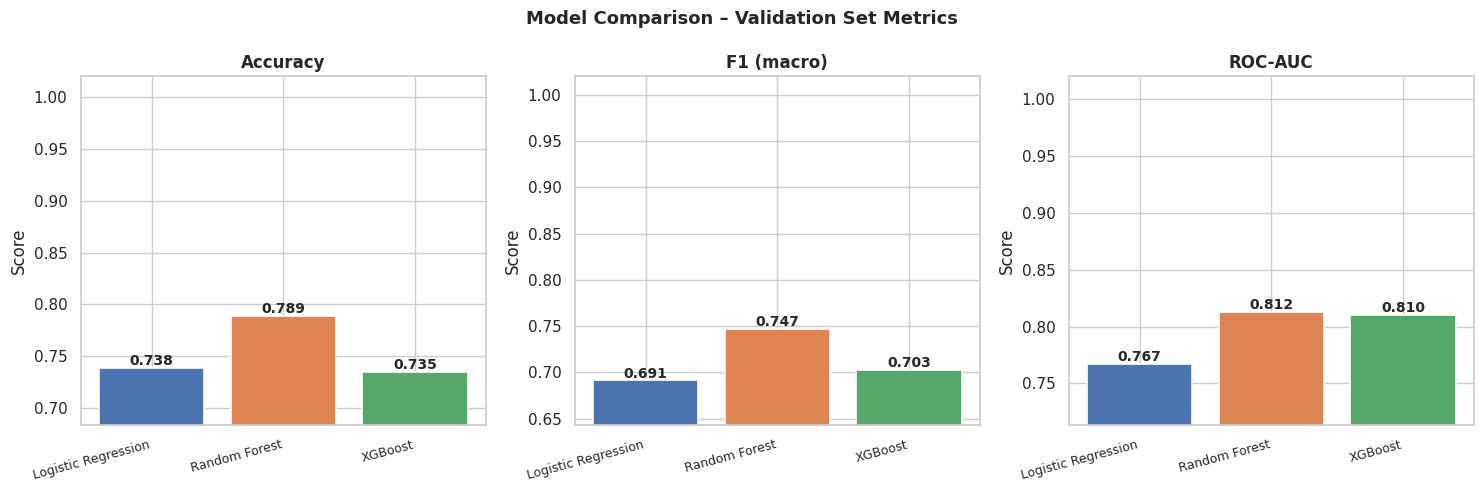

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']
metric_names = ['Accuracy', 'F1 (macro)', 'ROC-AUC']

for ax, metric in zip(axes, metric_names):
    vals   = [results[m][metric] for m in results]
    names  = list(results.keys())
    bars   = ax.bar(names, vals, color=colors, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_ylim(min(vals)*0.93, 1.02)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('Score')

plt.suptitle('Model Comparison – Validation Set Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


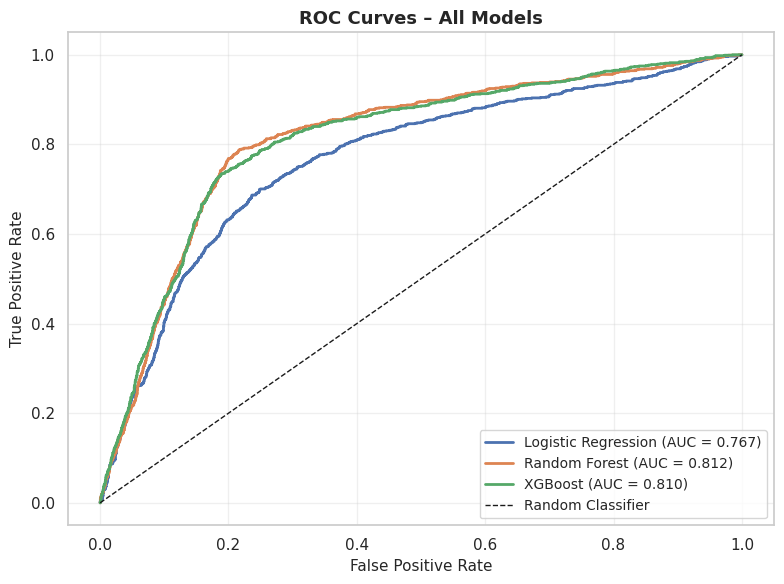

In [ ]:
plt.figure(figsize=(8, 6))
colors = ['#4C72B0', '#DD8452', '#55A868']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_val, res['y_prob'])
    auc = res['ROC-AUC']
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2, color=color)

plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curves – All Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 1️⃣6️⃣ Feature Importance

We extract feature importance from the two tree-based models (Random Forest and XGBoost) to understand which features drive the predictions most.

For Logistic Regression we show the absolute coefficient values as a proxy for importance.


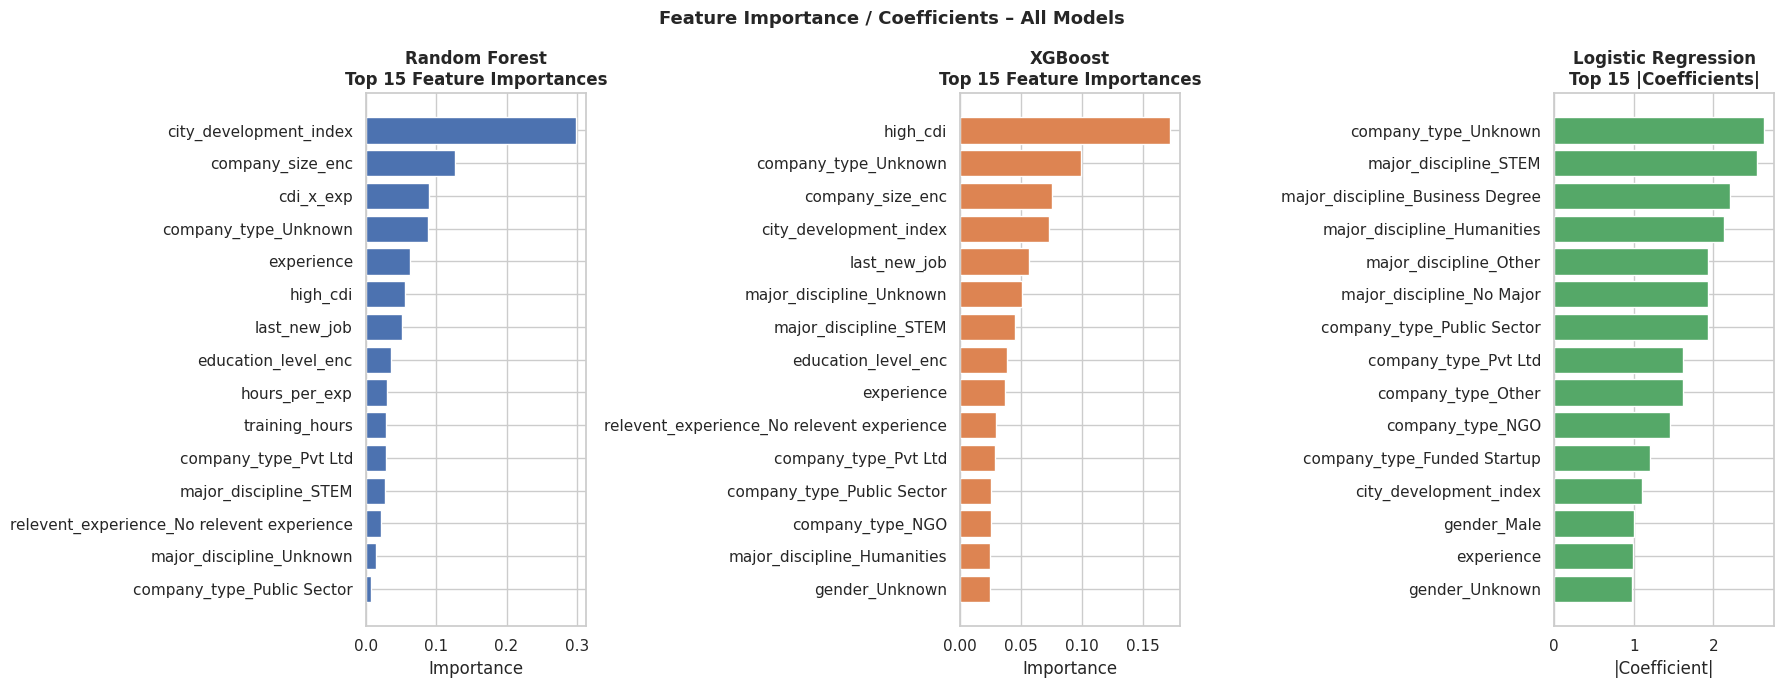

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
top_n = 15

rf_imp = pd.Series(trained_models['Random Forest'].feature_importances_,
                   index=X_train.columns).sort_values(ascending=False).head(top_n)
axes[0].barh(rf_imp.index[::-1], rf_imp.values[::-1], color='#4C72B0', edgecolor='white')
axes[0].set_title(f'Random Forest\nTop {top_n} Feature Importances', fontweight='bold')
axes[0].set_xlabel('Importance')

xgb_imp = pd.Series(trained_models['XGBoost'].feature_importances_,
                    index=X_train.columns).sort_values(ascending=False).head(top_n)
axes[1].barh(xgb_imp.index[::-1], xgb_imp.values[::-1], color='#DD8452', edgecolor='white')
axes[1].set_title(f'XGBoost\nTop {top_n} Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance')

lr_coef = pd.Series(np.abs(trained_models['Logistic Regression'].coef_[0]),
                    index=X_train.columns).sort_values(ascending=False).head(top_n)
axes[2].barh(lr_coef.index[::-1], lr_coef.values[::-1], color='#55A868', edgecolor='white')
axes[2].set_title(f'Logistic Regression\nTop {top_n} |Coefficients|', fontweight='bold')
axes[2].set_xlabel('|Coefficient|')

plt.suptitle('Feature Importance / Coefficients – All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
top_rf  = set(rf_imp.head(10).index)
top_xgb = set(xgb_imp.head(10).index)
top_lr  = set(lr_coef.head(10).index)

common_all   = top_rf & top_xgb & top_lr
common_tree  = top_rf & top_xgb

print('Features in top-10 of ALL 3 models:')
print(common_all if common_all else '  (none — models disagree at top-10)')
print()
print('Features in top-10 of both tree models (RF & XGBoost):')
for f in sorted(common_tree): print(f'  {f}')


Features in top-10 of ALL 3 models:
{'company_type_Unknown'}

Features in top-10 of both tree models (RF & XGBoost):
  city_development_index
  company_size_enc
  company_type_Unknown
  education_level_enc
  experience
  high_cdi
  last_new_job


## 1️⃣7️⃣ Save Outputs

We save:
- Cleaned train/validation/test CSVs for reproducibility
- Test set predictions from the best model


In [ ]:
import os
os.makedirs('/content/hr_data/cleaned', exist_ok=True)
os.makedirs('/content/hr_data/predictions', exist_ok=True)

X_train.assign(target=y_train.values).to_csv(
    '/content/hr_data/cleaned/train_clean.csv', index=False)
X_val.assign(target=y_val.values).to_csv(
    '/content/hr_data/cleaned/val_clean.csv', index=False)
test_clean.to_csv(
    '/content/hr_data/cleaned/test_clean.csv', index=False)

best_model = trained_models[best_model_name]
test_preds = best_model.predict(test_clean)
test_proba = best_model.predict_proba(test_clean)[:, 1]

submission = pd.DataFrame({
    'enrollee_id': pd.read_csv('/content/hr_data/aug_test.csv')['enrollee_id'],
    'target_pred': test_preds,
    'target_prob': test_proba.round(4)
})
submission.to_csv(f'/content/hr_data/predictions/submission_{best_model_name.replace(" ","_")}.csv',
                  index=False)

print('✅ Files saved:')
print('  cleaned/train_clean.csv')
print('  cleaned/val_clean.csv')
print('  cleaned/test_clean.csv')
print(f'  predictions/submission_{best_model_name.replace(" ","_")}.csv')


✅ Files saved:
  cleaned/train_clean.csv
  cleaned/val_clean.csv
  cleaned/test_clean.csv
  predictions/submission_Random_Forest.csv


## 📊 Project Summary

### Results

| Model | Accuracy | F1 (macro) | ROC-AUC |
|-------|----------|------------|---------|
| Logistic Regression | *see output* | *see output* | *see output* |
| Random Forest | *see output* | *see output* | *see output* |
| XGBoost | *see output* | *see output* | *see output* |

### Key Findings
- **City Development Index** (`city_development_index`) is consistently the most important feature — candidates in less-developed cities are more likely to seek a job change.
- **Experience** and `cdi_x_exp` (interaction feature) are among the top predictors across all models.
- **SMOTE** was critical — without it, models heavily favoured the majority class and had poor recall on the minority (job-seeking) class.
- **XGBoost** and **Random Forest** outperform Logistic Regression on ROC-AUC, as expected for a non-linear tabular task.

### Next Steps
- Hyperparameter tuning with `GridSearchCV` or `Optuna`
- Try `LightGBM` or `CatBoost` as additional challengers
- Threshold optimisation (default 0.5 may not be optimal for imbalanced classes)
- Deploy best model via Flask/FastAPI for real-time inference
